In [1]:
!pip install -q streamlit scikit-learn sentence-transformers faiss-cpu pandas groq pyngrok matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 122.2 MB/s eta 0:00:00


In [2]:
import os
os.environ["GROQ_API_KEY"] = "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"

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def load_model():

    df = pd.read_csv("/content/diabetes_integers_dataset.csv")

    gender_encoder = LabelEncoder()
    df["Gender"] = gender_encoder.fit_transform(df["Gender"])

    target_encoder = LabelEncoder()
    df["Diabetes_Type"] = target_encoder.fit_transform(df["Diabetes_Type"])

    X = df.drop("Diabetes_Type", axis=1)
    y = df["Diabetes_Type"]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "Accuracy": round(accuracy_score(y_test, y_pred)*100,2),
        "Precision": round(precision_score(y_test, y_pred, average="weighted")*100,2),
        "Recall": round(recall_score(y_test, y_pred, average="weighted")*100,2),
        "F1 Score": round(f1_score(y_test, y_pred, average="weighted")*100,2)
    }

    return model, target_encoder, scaler, metrics, X_scaled, y

rf_model, target_encoder, scaler, metrics, X_full, y_full = load_model()
print("Accuracy of model:", metrics['Accuracy'])
print("Precision of model:", metrics['Precision'])
print("Recall of model:", metrics['Recall'])
print("F1 Score of model:", metrics['F1 Score'])

Accuracy of model: 96.35
Precision of model: 96.43
Recall of model: 96.35
F1 Score of model: 96.36


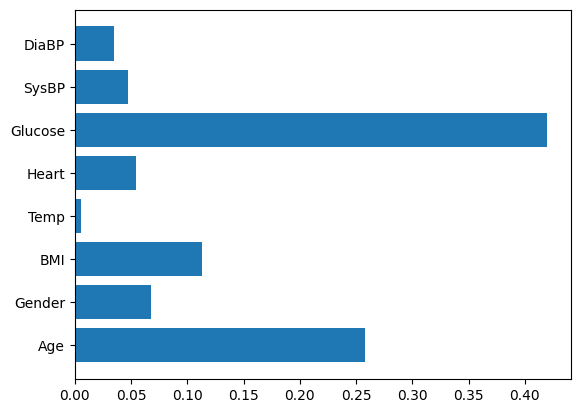

In [4]:
import matplotlib.pyplot as plt

# st.subheader("Feature Importance") # Removed: st is not defined here

importances = rf_model.feature_importances_
features = ["Age","Gender","BMI","Temp","Heart","Glucose","SysBP","DiaBP"]

fig, ax = plt.subplots()
ax.barh(features, importances)
plt.show() # Changed from st.pyplot(fig) to plt.show() to display in Colab

In [5]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import os
import sqlite3
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sentence_transformers import SentenceTransformer
import faiss
from groq import Groq

# ---------------------------
# DATABASE SETUP
# ---------------------------
DB_PATH = "diabetes_app.db"

def create_tables():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS patients (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        Time TEXT,
        Age INTEGER,
        Gender TEXT,
        BMI REAL,
        Glucose REAL,
        Prediction TEXT,
        Risk INTEGER,
        Suggestion TEXT,
        Diet TEXT
    )
    """)

    conn.commit()
    conn.close()

create_tables()



# ---------------------------
# Session Memory
# ---------------------------
if "chat_history" not in st.session_state:
    st.session_state.chat_history = []

if "patient_history" not in st.session_state:
    st.session_state.patient_history = []

# ---------------------------
# Load & Train Model (Improved)
# ---------------------------
@st.cache_resource
def load_model():

    df = pd.read_csv("/content/diabetes_integers_dataset.csv")

    gender_encoder = LabelEncoder()
    df["Gender"] = gender_encoder.fit_transform(df["Gender"])

    target_encoder = LabelEncoder()
    df["Diabetes_Type"] = target_encoder.fit_transform(df["Diabetes_Type"])

    X = df.drop("Diabetes_Type", axis=1)
    y = df["Diabetes_Type"]

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = {
        "Accuracy": round(accuracy_score(y_test, y_pred)*100,2),
        "Precision": round(precision_score(y_test, y_pred, average="weighted")*100,2),
        "Recall": round(recall_score(y_test, y_pred, average="weighted")*100,2),
        "F1 Score": round(f1_score(y_test, y_pred, average="weighted")*100,2)
    }

    return model, target_encoder, scaler, metrics

rf_model, target_encoder, scaler, metrics = load_model()

# ---------------------------
# RAG Setup
# ---------------------------
@st.cache_resource
def load_rag():
    with open("/content/Major Project Data for diabetes from CDC.txt", "r") as f:
        text = f.read()

    chunks = text.split("\n\n")
    embed_model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = embed_model.encode(chunks)

    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(np.array(embeddings))

    return embed_model, index, chunks

embed_model, index, chunks = load_rag()

client = Groq(api_key=os.environ["GROQ_API_KEY"])

def query_llama(messages):
    response = client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        messages=messages,
        temperature=0.6,
        max_tokens=500
    )
    return response.choices[0].message.content

# ---------------------------
# BMI
# ---------------------------
def calculate_bmi(weight, height_cm):
    height_m = height_cm / 100
    return round(weight / (height_m ** 2), 2)
# ---------------------------
# risk factor
# ---------------------------


def calculate_risk(glucose, bmi, age, heart):

    risk = 0

    if glucose > 140:
        risk += 40
    elif glucose > 110:
        risk += 25

    if bmi > 30:
        risk += 25
    elif bmi > 25:
        risk += 15

    if age > 45:
        risk += 20

    if heart > 100:
        risk += 10

    return min(risk, 100)

# ---------------------------
# diet suggestion
# ---------------------------

def diet_plan(glucose):

    if glucose > 180:
        return "Avoid sweets, white rice, sugary drinks."

    elif glucose > 140:
        return "Eat more vegetables, reduce carbohydrates."

    else:
        return "Balanced diet recommended."

# ---------------------------
# Simple Suggestion
# ---------------------------
def simple_suggestion(pred, glucose, bmi, heart):

    if pred == "Type 2":
        return """
• Reduce sugar and refined carbohydrates
• Daily walking 30 minutes
• Monitor blood glucose weekly
• Maintain BMI below 25
"""

    elif pred == "Type 1":
        return """
• Insulin therapy required
• Regular blood sugar monitoring
• Consult endocrinologist immediately
"""

    elif pred == "Gestational Diabetes":
        return """
• Monitor glucose daily
• Follow pregnancy diet plan
• Consult gynecologist
"""

    elif glucose > 180:
        return "⚠️ Very high glucose. Immediate medical consultation required."

    else:
        return "Healthy lifestyle recommended."

# ---------------------------
# SAVE PATIENT TO DB
# ---------------------------
def save_patient(record):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO patients (Time, Age, Gender, BMI, Glucose, Prediction, Risk, Suggestion, Diet)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        str(datetime.now()),
        record["Age"],
        record["Gender"],
        record["BMI"],
        record["Glucose"],
        record["Prediction"],
        record["Diabetes Risk Score"],
        record["Suggestion"],
        record["Diet Advice"]
    ))

    conn.commit()
    conn.close()
# ---------------------------
# SAVE PATIENT TO DB
# ---------------------------
def save_patient(record):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO patients (Time, Age, Gender, BMI, Glucose, Prediction, Risk, Suggestion, Diet)
    VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        str(datetime.now()),
        record["Age"],
        record["Gender"],
        record["BMI"],
        record["Glucose"],
        record["Prediction"],
        record["Diabetes Risk Score"],
        record["Suggestion"],
        record["Diet Advice"]
    ))

    conn.commit()
    conn.close()
# ---------------------------
# LOAD PATIENT DATA
# ---------------------------
def load_patients():
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query("SELECT * FROM patients", conn)
    conn.close()
    return df

# ---------------------------
# Prediction
# ---------------------------
def predict_diabetes(age, gender, bmi, temp, heart, glucose, sys, dia):

    gender_encoded = 1 if gender == "Male" else 0

    if gender == "Female" and 20 <= age <= 45 and glucose > 140:
        return "Gestational"

    input_data = [[age, gender_encoded, bmi, temp, heart, glucose, sys, dia]]
    input_data = scaler.transform(input_data)

    prediction = rf_model.predict(input_data)

    return target_encoder.inverse_transform(prediction)[0]

# ---------------------------
# RAG + Memory
# ---------------------------
def rag_answer(question, patient_data):

    query_embedding = embed_model.encode([question])
    D, I = index.search(np.array(query_embedding), k=3)

    context = " ".join([chunks[i] for i in I[0]])

    messages = [
        {"role": "system", "content": "You are a medical AI assistant."},
        {"role": "system", "content": f"Patient Data: {patient_data}"},
        {"role": "system", "content": f"Medical Context: {context}"}
    ]

    messages.extend(st.session_state.chat_history)
    messages.append({"role": "user", "content": question})

    answer = query_llama(messages)

    st.session_state.chat_history.append({"role": "user", "content": question})
    st.session_state.chat_history.append({"role": "assistant", "content": answer})

    return answer

# ---------------------------
# UI
# ---------------------------
st.title("FINAL AI Diabetes System")

#st.subheader("Model Accuracy")
#st.write(metrics)

st.header("Hello, Enter your Details")

age = st.number_input("Age", 1)
gender = st.selectbox("Gender", ["Male", "Female"])
weight = st.number_input("Weight (kg)")
height = st.number_input("Height (cm)")
temp = st.number_input("Temperature")
heart = st.number_input("Heart Rate")
glucose = st.number_input("Glucose")
sys = st.number_input("Systolic BP")
dia = st.number_input("Diastolic BP")

bmi = calculate_bmi(weight, height)
st.info(f"BMI: {bmi}")

if st.button("Predict"):

    prediction = predict_diabetes(age, gender, bmi, temp, heart, glucose, sys, dia)
    suggestion = simple_suggestion(prediction, glucose, bmi, heart)
    risk = calculate_risk(glucose, bmi, age, heart)
    st.success(f"Prediction: {prediction}")
    st.info(f"Suggestion: {suggestion}")
    st.warning(f"Diabetes Risk Score: {risk}%")
    st.info(f"Diet Advice: {diet_plan(glucose)}")

    record = {
        "Time": datetime.now(),
        "Age": age,
        "Gender": gender,
        "BMI": bmi,
        "Glucose": glucose,
        "Prediction": prediction,
        "Diabetes Risk Score": risk,
        "Suggestion": suggestion,
        "Diet Advice": diet_plan(glucose),

    }

    st.session_state.patient_history.append(record)
    record = {
        "Age": age,
        "Gender": gender,
        "BMI": bmi,
        "Glucose": glucose,
        "Prediction": prediction,
        "Diabetes Risk Score": risk,
        "Suggestion": suggestion,
        "Diet Advice": diet_plan(glucose),
    }
    save_patient(record)

st.subheader("Patient History")
st.dataframe(load_patients())
st.subheader("Model Accuracy")
st.write(metrics)

st.header("Chat with AI")

question = st.text_area("Ask your question")

if st.button("Send"):
    answer = rag_answer(question, {"Age": age, "BMI": bmi, "Glucose": glucose})
    st.write(answer)

# ---------------------------
# Show History
# ---------------------------
st.subheader("Patient History")
if st.session_state.patient_history:
    st.dataframe(pd.DataFrame(st.session_state.patient_history))

st.subheader("Conversation History")
for msg in st.session_state.chat_history:
    if msg["role"] == "user":
        st.write("🧑:", msg["content"])
    else:
        st.write("🤖:", msg["content"])

Writing app.py


In [6]:
import os
!pip install pyngrok
from pyngrok import ngrok
import subprocess
ngrok.set_auth_token("3AFp5iGk4vNRMrI7xiuZPOQ2lye_3pNWMx7rTHSzce6Tyj5BH")

# Terminate any existing ngrok processes to free up the session
ngrok.kill()

public_url = ngrok.connect(8501)
print("App URL:", public_url)

subprocess.Popen(["streamlit", "run", "app.py"])

App URL: NgrokTunnel: "https://e9ea-34-138-160-93.ngrok-free.app" -> "http://localhost:8501"


<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>